<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/6_Bidirectional_Long_Short_Term_Memory_(BiLSTM)_Cell_Mechanics_from_Scratch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
batch_size = 2
sequence_length = 6
input_size = 4
hidden_size = 5

X = torch.randn(batch_size, sequence_length, input_size)

print("Input Shape:", X.shape)

Input Shape: torch.Size([2, 6, 4])


In [3]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    return torch.tanh(x)

In [4]:
def initialize_weights():

    weights = {}

    gates = ['i','f','o','g']

    for gate in gates:

        weights["W"+gate] = torch.randn(input_size, hidden_size) * 0.1
        weights["U"+gate] = torch.randn(hidden_size, hidden_size) * 0.1
        weights["b"+gate] = torch.zeros(hidden_size)

    return weights

forward_weights = initialize_weights()
backward_weights = initialize_weights()

In [5]:
def lstm_cell(x_t, h_prev, c_prev, w):

    i = sigmoid(x_t @ w["Wi"] + h_prev @ w["Ui"] + w["bi"])

    f = sigmoid(x_t @ w["Wf"] + h_prev @ w["Uf"] + w["bf"])

    o = sigmoid(x_t @ w["Wo"] + h_prev @ w["Uo"] + w["bo"])

    g = tanh(x_t @ w["Wg"] + h_prev @ w["Ug"] + w["bg"])

    c = f * c_prev + i * g

    h = o * tanh(c)

    return h, c

In [6]:
forward_outputs = []

h = torch.zeros(batch_size, hidden_size)
c = torch.zeros(batch_size, hidden_size)

for t in range(sequence_length):

    h, c = lstm_cell(
        X[:, t],
        h,
        c,
        forward_weights
    )

    forward_outputs.append(h)

forward_outputs = torch.stack(forward_outputs, dim=1)

print("Forward Output Shape:", forward_outputs.shape)

Forward Output Shape: torch.Size([2, 6, 5])


In [7]:
backward_outputs = []

h = torch.zeros(batch_size, hidden_size)
c = torch.zeros(batch_size, hidden_size)

for t in reversed(range(sequence_length)):

    h, c = lstm_cell(
        X[:, t],
        h,
        c,
        backward_weights
    )

    backward_outputs.append(h)

backward_outputs.reverse()

backward_outputs = torch.stack(backward_outputs, dim=1)

print("Backward Output Shape:", backward_outputs.shape)

Backward Output Shape: torch.Size([2, 6, 5])


In [8]:
bilstm_output = torch.cat(
    (forward_outputs, backward_outputs),
    dim=2
)

print("BiLSTM Output Shape:", bilstm_output.shape)

BiLSTM Output Shape: torch.Size([2, 6, 10])


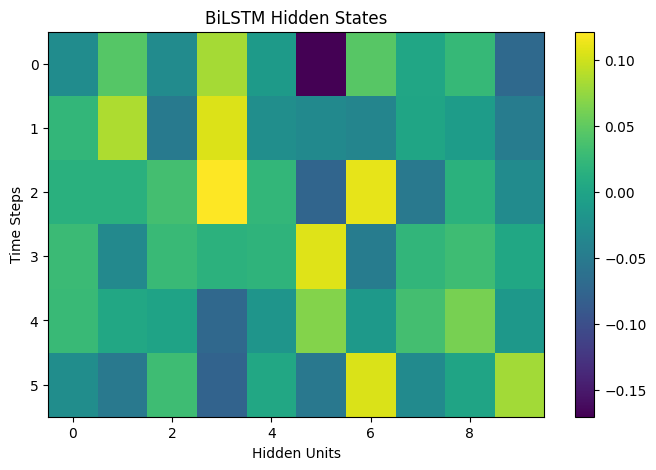

In [9]:
plt.figure(figsize=(8,5))

plt.imshow(
    bilstm_output[0].detach().numpy(),
    cmap="viridis",
    aspect="auto"
)

plt.colorbar()

plt.title("BiLSTM Hidden States")

plt.xlabel("Hidden Units")

plt.ylabel("Time Steps")

plt.show()

In [10]:
print("Forward Final Hidden State")

print(forward_outputs[:, -1])

print()

print("Backward Final Hidden State")

print(backward_outputs[:, 0])

print()

print("BiLSTM Final Output")

print(bilstm_output.shape)

Forward Final Hidden State
tensor([[-0.0272, -0.0526,  0.0311, -0.0771,  0.0046],
        [-0.0071, -0.1187,  0.1196,  0.0444,  0.0590]])

Backward Final Hidden State
tensor([[-0.1702,  0.0455,  0.0028,  0.0253, -0.0703],
        [ 0.0199,  0.0630,  0.0114,  0.0474,  0.0234]])

BiLSTM Final Output
torch.Size([2, 6, 10])


In [11]:
print("========== SUMMARY ==========")

print("Sequence Length :", sequence_length)

print("Input Features :", input_size)

print("Hidden Units :", hidden_size)

print("Forward Shape :", forward_outputs.shape)

print("Backward Shape :", backward_outputs.shape)

print("BiLSTM Shape :", bilstm_output.shape)

print("=============================")

========== SUMMARY ==========
Sequence Length : 6
Input Features : 4
Hidden Units : 5
Forward Shape : torch.Size([2, 6, 5])
Backward Shape : torch.Size([2, 6, 5])
BiLSTM Shape : torch.Size([2, 6, 10])
